In [4]:
# # 02 - Feature engineering
#
# Builds two model-ready tables and the time-aware splits.
#
# | Target | Grain | Rate |
# |---|---|---|
# | `target_repeat` - returned within 180 days | customer | ~1.8% |
# | `target_low_review` - review score <= 2 | order | ~12.8% |
#
# Requirements carried over from the EDA:
# 1. Threshold features around the promised date (G17: a cliff, not a slope)
# 2. Order-month controls (E14: monthly late rate swings ~1% to ~21%)
# 3. `has_comment` as a feature (G18: 2.1x more likely on 1-star)
# 4. `is_split_order` flag (B6: `is_late` unreliable for multi-seller orders)
#

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root :", ROOT)
print("src/ found   :", (ROOT / "src").is_dir())

project root : c:\DS-AI-Spiced\EcomIQ_AI_Powered_Ecom_Platform
src/ found   : True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.prepare import build_order_frame
from src.features.build import (
    CHURN_HORIZON_DAYS,
    LATE_THRESHOLDS,
    LOW_REVIEW_THRESHOLD,
    build_churn_features,
    build_review_features,
    split_summary,
    time_split,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
print("ready")

ready


In [ ]:
order_frame = build_order_frame()
print(f"{len(order_frame):,} orders x {order_frame.shape[1]} cols")

99,441 orders x 41 cols


In [5]:
# ## Target 1 - churn (repeat purchase within 180 days)
#
# Cohort rule: the first order must fall at least 180 days before 2018-08-31,
# otherwise "hasn't returned yet" gets mislabelled as churned. That is why the
# window ends 2018-03-03.

churn = build_churn_features(order_frame, horizon_days=CHURN_HORIZON_DAYS)

print(f"rows       {len(churn):,}")
print(f"positives  {churn.target_repeat.sum():,} ({churn.target_repeat.mean():.2%})")
print(f"window     {churn.order_purchase_timestamp.min().date()} .. "
      f"{churn.order_purchase_timestamp.max().date()}")
print(f"features   {churn.shape[1] - 3}")
churn.head(3)

c:\DS-AI-Spiced\EcomIQ_AI_Powered_Ecom_Platform\src\features\build.py:128: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_comment"] = df["has_comment"].fillna(False).astype("float")


rows       57,049
positives  1,024 (1.79%)
window     2017-01-05 .. 2018-03-03
features   29


,customer_unique_id,order_purchase_timestamp,revenue,log_revenue,freight,freight_ratio,avg_item_price,n_items,n_distinct_products,n_sellers,n_categories,total_weight_g,max_installments,n_payment_methods,delivery_days,days_late,days_early,late_over_0d,late_over_3d,late_over_7d,is_split_order,late_flag_reliable,review_score,has_comment,comment_length,month_index,month_of_year,dow,customer_state,primary_category,primary_payment_type,target_repeat
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,69.00,4.248495,17.22,0.249565,69.00,1.0,1.0,1.0,1.0,1500.0,8.0,1.0,25.731759,0.0,1.389734,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,2.0,3.0,4.0,SC,papelaria,credit_card,0
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,25.99,3.295466,17.63,0.678338,25.99,1.0,1.0,1.0,1.0,150.0,4.0,1.0,20.037083,0.0,11.108970,0.0,0.0,0.0,0.0,1.0,4.0,1.0,12.0,9.0,10.0,3.0,PA,telefonia,credit_card,0
2,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,180.00,5.198497,16.89,0.093833,180.00,1.0,1.0,1.0,1.0,6050.0,6.0,1.0,13.141134,0.0,7.035463,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,10.0,11.0,1.0,SP,telefonia,credit_card,0


In [6]:
# ## Target 2 - low review score (<= 2 stars)
#
# `has_comment` and `comment_length` are deliberately EXCLUDED here: both are
# properties of the review itself, so using them to predict the score is
# circular. They stay in the churn table, where the review already happened.

reviews = build_review_features(order_frame, threshold=LOW_REVIEW_THRESHOLD)

print(f"rows       {len(reviews):,}")
print(f"positives  {reviews.target_low_review.sum():,} "
      f"({reviews.target_low_review.mean():.2%})")
print(f"features   {reviews.shape[1] - 4}")
reviews.head(3)

# ## Sanity check - do the threshold features carry the G17 signal?

rows       95,568
positives  12,229 (12.80%)
features   27


,order_id,customer_unique_id,order_purchase_timestamp,revenue,log_revenue,freight,freight_ratio,avg_item_price,n_items,n_distinct_products,n_sellers,n_categories,total_weight_g,max_installments,n_payment_methods,delivery_days,days_late,days_early,approval_hours,late_over_0d,late_over_3d,late_over_7d,is_split_order,late_flag_reliable,month_index,month_of_year,dow,customer_state,primary_category,primary_payment_type,target_low_review
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,29.99,3.433665,8.72,0.290764,29.99,1.0,1.0,1.0,1.0,500.0,1.0,3.0,8.436574,0.0,7.107488,0.178333,0.0,0.0,0.0,0.0,1.0,9.0,10.0,0.0,SP,utilidades_domesticas,voucher,0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,118.70,4.784989,22.76,0.191744,118.70,1.0,1.0,1.0,1.0,400.0,1.0,1.0,13.782037,0.0,5.355729,30.713889,0.0,0.0,0.0,0.0,1.0,18.0,7.0,1.0,BA,perfumaria,boleto,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,159.90,5.080783,19.22,0.120200,159.90,1.0,1.0,1.0,1.0,420.0,3.0,1.0,9.394213,0.0,17.245498,0.276111,0.0,0.0,0.0,0.0,1.0,19.0,8.0,2.0,GO,automotivo,credit_card,0


In [7]:
for t in LATE_THRESHOLDS:
    col = f"late_over_{t}d"
    g = reviews.groupby(col, observed=True)["target_low_review"].agg(["mean", "size"])
    print(f"{col}:  not-late {g['mean'].iloc[0]:.1%} (n={g['size'].iloc[0]:,})"
          f"   |   late {g['mean'].iloc[1]:.1%} (n={g['size'].iloc[1]:,})")

late_over_0d:  not-late 9.2% (n=87,902)   |   late 54.0% (n=7,658)
late_over_3d:  not-late 9.5% (n=90,537)   |   late 72.4% (n=5,023)
late_over_7d:  not-late 10.5% (n=92,310)   |   late 78.4% (n=3,250)


In [8]:
# ## Missing values
#
# XGBoost handles NaN natively - do NOT impute. Nulls mean "never delivered",
# which is real information and describes the angriest customers.

for name, df in [("churn", churn), ("reviews", reviews)]:
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    print(f"\n{name}: {len(nulls)} columns with nulls")
    if len(nulls):
        print((nulls / len(df)).round(4).head(10).to_string())


churn: 9 columns with nulls
delivery_days       0.0196
days_late           0.0196
days_early          0.0196
late_over_0d        0.0196
late_over_3d        0.0196
late_over_7d        0.0196
primary_category    0.0185
review_score        0.0082
comment_length      0.0082

reviews: 8 columns with nulls
primary_category    0.0141
approval_hours      0.0001
delivery_days       0.0001
days_late           0.0001
days_early          0.0001
late_over_0d        0.0001
late_over_3d        0.0001
late_over_7d        0.0001


In [9]:
# ## Time-aware split
#
# Never a random split. Both targets involve a future event, so a random split
# lets the model train on later months and predict earlier ones - optimistic
# scores that will not survive deployment.

churn_train, churn_test = time_split(churn, test_size=0.2)
review_train, review_test = time_split(reviews, test_size=0.2)

print("CHURN")
print(split_summary(churn_train, churn_test, "target_repeat").to_string())
print("\nREVIEWS")
print(split_summary(review_train, review_test, "target_low_review").to_string())

CHURN
        rows  positives  positive_rate       start         end
train  45639        839       0.018383  2017-01-05  2018-01-12
test   11410        185       0.016214  2018-01-12  2018-03-03

REVIEWS
        rows  positives  positive_rate       start         end
train  76454      10382       0.135794  2017-01-05  2018-05-27
test   19114       1847       0.096631  2018-05-27  2018-08-29


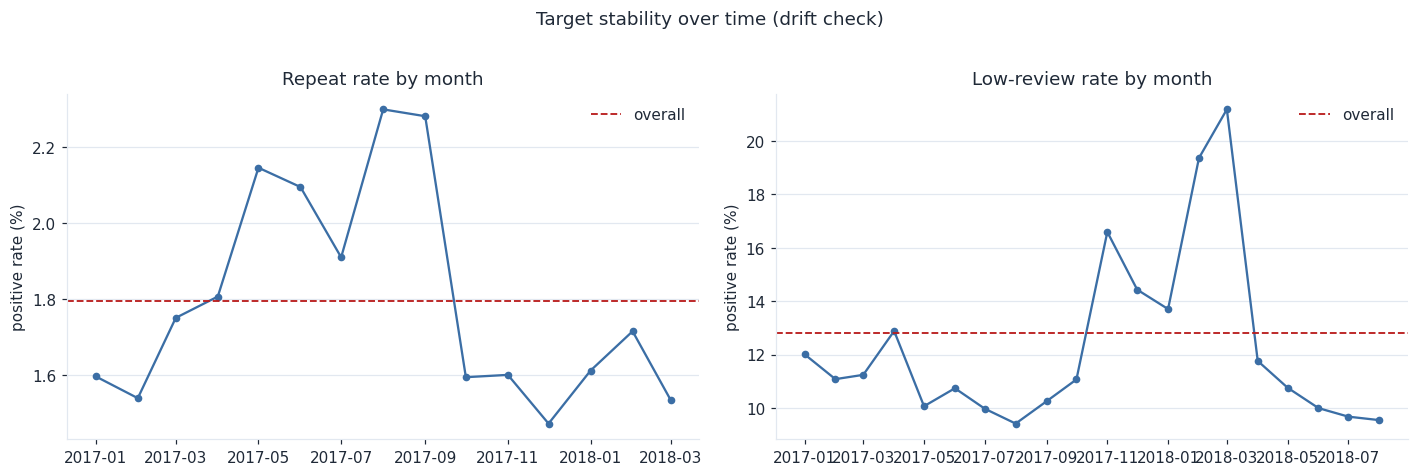

In [10]:
# Expect the review test rate to be LOWER than train (~9.7% vs ~13.6%). That is
# the E14 delivery drift - performance genuinely improved through 2018, so the
# test period has fewer bad reviews. `month_index` is in the feature set to
# absorb it.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (df, target, title) in zip(axes, [
    (churn, "target_repeat", "Repeat rate by month"),
    (reviews, "target_low_review", "Low-review rate by month"),
]):
    monthly = df.set_index("order_purchase_timestamp")[target].resample("MS").mean()
    ax.plot(monthly.index, monthly * 100, marker="o", ms=4, color=PALETTE[0])
    ax.axhline(df[target].mean() * 100, color=PALETTE[3], ls="--", lw=1.2,
               label="overall")
    ax.set_ylabel("positive rate (%)")
    ax.set_title(title)
    ax.legend()

fig.suptitle("Target stability over time (drift check)", y=1.02)
fig.tight_layout()
plt.show()

In [11]:
# ## Save
#
# Parquet preserves dtypes and NaN semantics. CSV would turn booleans into
# strings and lose the distinction between NaN and empty.

churn.to_parquet(PROCESSED / "churn_features.parquet", index=False)
reviews.to_parquet(PROCESSED / "review_features.parquet", index=False)

for name in ["churn_features", "review_features"]:
    p = PROCESSED / f"{name}.parquet"
    print(f"{name:20s} {p.stat().st_size / 1e6:.1f} MB")

# ## Next: modelling
#
# Churn: 1,024 positives in 57k rows. Use `scale_pos_weight`, evaluate with
# PR-AUC, tune the threshold on the precision-recall curve. Expect modest lift.
#
# Low review: 12.8% positive and far more learnable. Comparing the two is the
# interesting result.

churn_features       4.5 MB
review_features      11.1 MB
